In [119]:
print("all okay")

all okay


In [120]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [121]:
# print("")

In [122]:
from langchain_openai import ChatOpenAI

In [123]:
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

In [124]:
chat_llm = ChatGroq(model = "llama-3.3-70b-versatile")

In [125]:
chat_llm.invoke("Hello, how are you?").content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?"

In [126]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [127]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [128]:
{
    "messages": [HumanMessage(content="Hi, this is Anees. Say Hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Anees. Say Hello in detail.', additional_kwargs={}, response_metadata={})]}

In [129]:
["Hye"]

['Hye']

In [130]:
["Hye", "How are you?"]

['Hye', 'How are you?']

In [131]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI responses."""
    response = chat_llm.invoke(state["messages"]) # AI message
    return {
        "messages": [response]
    }


In [132]:
def token_counter(state: GraphState) -> dict:
    """count tokens (simple word count) in the last AI message"""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [133]:
from langgraph.graph import StateGraph

In [134]:
builder = StateGraph(GraphState)

In [135]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [136]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [137]:
app = builder.compile()

In [138]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [139]:
from IPython.display import Image, display

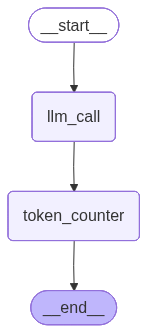

In [140]:
display(Image(app.get_graph().draw_mermaid_png()))

In [141]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Anees. Say Hello in detail.")]
})

In [142]:
result

{'messages': [HumanMessage(content='Hi, this is Anees. Say Hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Anees, it's an absolute delight to connect with you. I hope this message finds you in the best of spirits and having a fantastic day. I'm more than happy to have the opportunity to interact with you and assist you in any way I can.\n\nAs we begin our conversation, I want to assure you that I'm here to provide you with accurate and helpful information, answer any questions you may have, and engage in a productive and friendly discussion. My purpose is to help you find the information you're looking for, provide guidance, and learn from your experiences and perspectives as well.\n\nPlease feel free to share your thoughts, ask questions, or discuss any topics that interest you. I'm all ears and ready to respond with detailed and informative answers. Whether you're looking for knowledge on a specific subject, need help with a problem, or just

In [143]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Anees. Say Hello in detail.
AIMessage : Hello Anees, it's an absolute delight to connect with you. I hope this message finds you in the best of spirits and having a fantastic day. I'm more than happy to have the opportunity to interact with you and assist you in any way I can.

As we begin our conversation, I want to assure you that I'm here to provide you with accurate and helpful information, answer any questions you may have, and engage in a productive and friendly discussion. My purpose is to help you find the information you're looking for, provide guidance, and learn from your experiences and perspectives as well.

Please feel free to share your thoughts, ask questions, or discuss any topics that interest you. I'm all ears and ready to respond with detailed and informative answers. Whether you're looking for knowledge on a specific subject, need help with a problem, or just want to chat, I'm here to listen and assist you to the best of my abilities.

So

In [144]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B9FB16D0D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B9FD82B710>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [145]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [146]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [147]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [148]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data.\nThese models learn the underlying patterns and structures of their training data and use them to generate new data\nin response to input, which often takes the form of natural language prompts.\nThe generated material is often cal'

In [149]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [150]:
print(TAVILY_API_KEY)

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


In [151]:
tool = TavilySearchResults(tavily_api_key = TAVILY_API_KEY)

In [152]:
tool.invoke({"query": "What is the latest news about generative AI?"})

[{'title': 'Generative AI news and analysis',
  'url': 'https://techcrunch.com/tag/generative-ai/',
  'content': '### Topics\n\nLatest\n\nAI\n\nAmazon\n\nApps\n\nBiotech & Health\n\nClimate\n\nCloud Computing\n\nCommerce\n\nCrypto\n\nEnterprise\n\nEVs\n\nFintech\n\nFundraising\n\nGadgets\n\nGaming\n\nGoogle\n\nGovernment & Policy\n\nHardware\n\nInstagram\n\nLayoffs\n\nMedia & Entertainment\n\nMeta\n\nMicrosoft\n\nPrivacy\n\nRobotics\n\nSecurity\n\nSocial\n\nSpace\n\nStartups\n\nTikTok\n\nTransportation\n\nVenture\n\n### More from TechCrunch\n\nStaff\n\nEvents\n\nStartup Battlefield\n\nStrictlyVC\n\nNewsletters\n\nPodcasts\n\nVideos\n\nPartner Content\n\nTechCrunch Brand Studio\n\nCrunchboard\n\nContact Us\n\n# Generative AI\n\nTechCrunch covers the latest news and analysis in Generative AI (GenAI). Read the latest on startups and founders building artificial intelligence tools. From OpenAI with ChatGPT, to Google with Gemini—TechCrunch covers the entire ecosystem.\n\n### \n\nSpotify lo

In [153]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [154]:
search.invoke("What is the latest update on Iphone 17 release?")

"Apple’s newest phones are called the iPhone 17 , iPhone 17 Pro, iPhone 17 Pro Max, and the iPhone Air (it’s not the iPhone 17 Air). The Air is a brand new category of iPhone . Apple’s new iPhones for 2025 are available to pre-order now and start shipping Friday, September 19. Just turn on automatic updates , and your iPhone stays current with the latest features and security. An array of iPhone 17 and 17 Pro devices each with a different screen showcasing iOS 26 and Apple Intelligence features. Supersmart, superspeedy Apple silicon. Get the latest software updates from Apple. Keeping your software up to date is one of the most important things you can do to maintain your Apple product's security. The latest version of iOS and iPadOS is 26.3. Learn how to update the software on your iPhone or iPad. Apple iPhone 17 Pro Release Date Latest News: What To Expect When And Where. Apple’s first iPhone update of the new year will be iOS 26.3, which just recently debuted in beta. Here’s the exp

"2 weeks ago - It was announced on June 5, 2023, at Apple's annual Worldwide Developers Conference alongside watchOS 10, iPadOS 17, tvOS 17 and macOS Sonoma. It was made publicly available on September 18, 2023 , as a free software update for supported iOS devices (see the supported devices section). 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... October 9, 2025 - The iPhone 17e is rumoured to launch in the spring of 2026 . Read on for more detailed analysis of the new iPhone 17 colors, cameras, battery life, specs, and features, plus the iPhone 17 release date and pricing. 5 days ago - ... In the iOS 26.4 update that's coming this spring, Apple will introduce a new version of Siri that's going to overhaul how we interact with the personal assistant and what it's able to do."

In [155]:
from langchain_community.tools import YouTubeSearchTool


In [156]:
tool = YouTubeSearchTool()

In [157]:
tool.name

'youtube_search'

In [158]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [159]:
tool.run("langgraph tutorial")

"['https://www.youtube.com/watch?v=CnXdddeZ4tQ&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs']"

"['https://www.youtube.com/watch?v=CnXdddeZ4tQ&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs']"

In [160]:
def multiply(a:int, b:int) -> int:
    return a * b

In [161]:
multiply(10, 4)

40

In [162]:
from langchain.tools import tool

In [163]:
@tool
def multiply(a:int, b:int) -> int:
    """This tool is for the multiplication"""
    return a * b

In [164]:
multiply.invoke({"a": 10, "b": 4})

40

In [165]:
multiply.name

'multiply'

In [166]:
multiply.description

'This tool is for the multiplication'

In [167]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [168]:
@tool
def get_word_length(word:str) -> int:
    """This is custom tool to count the length of the word"""
    return len(word)

In [169]:
get_word_length.invoke("hello world")

11

In [170]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api"""
    pass

In [171]:
@tool
def call_sqlitedb(args):
    """this is a tool to call sqlite db"""
    pass

In [172]:
import yfinance as yf

In [173]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [174]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2695.60.'

In [175]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $261.73.'

In [176]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $417.07.'

In [177]:
get_stock_price.invoke("HRL")

'The last closing price of HRL was $23.44.'

In [178]:
tools = [get_stock_price, get_word_length, multiply, wiki_tool]

In [179]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B9FB16D0D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B9FD82B710>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [181]:
llm_with_tool = chat_llm.bind_tools(tools)

In [184]:
result = llm_with_tool.invoke("What is the stock price of TCS.NS?")

In [185]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h9dxm2fwa', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 475, 'total_tokens': 493, 'completion_time': 0.04879033, 'completion_tokens_details': None, 'prompt_time': 0.066545529, 'prompt_tokens_details': None, 'queue_time': 0.048702887, 'total_time': 0.115335859}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c566f-17ce-7c01-9ed8-0316423d22da-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'h9dxm2fwa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 475, 'output_tokens': 18, 'total_tokens': 493})

In [186]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'h9dxm2fwa',
  'type': 'tool_call'}]

In [191]:
result = llm_with_tool.invoke("How many latters are there in sentence 'how are you'?")

In [192]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'how are you'},
  'id': 'msqwg18jg',
  'type': 'tool_call'}]

In [193]:
result.content

''

In [194]:
result = llm_with_tool.invoke("can you multiply 10 and 20?")

In [195]:
result.content

''

In [196]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': '3wxw2thra',
  'type': 'tool_call'}]

In [197]:
result = llm_with_tool.invoke("hye! how are you?")

In [198]:
result.content

"I'm just a language model, I don't have feelings or emotions, but I'm here to help you with any questions or tasks you may have. How can I assist you today?"

In [199]:
result.tool_calls

[]

In [201]:
result = llm_with_tool.invoke("what was in the latest indian union budget report of 2026?")

In [202]:
result.content

''

In [210]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'g5xn0k2j0',
  'type': 'tool_call'}]

In [213]:
result.content

''

In [214]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'g5xn0k2j0',
  'type': 'tool_call'}]

In [217]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition


In [216]:
def function_1(state:MessagesState):
    pass

In [218]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001B9FD993D80>),
 StructuredTool(name='get_word_length', description='This is custom tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001B9FD991260>),
 StructuredTool(name='multiply', description='This tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001B9FD990900>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Lenovo\\Agentic-AI-system\\agentenv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [219]:
function_2 = ToolNode(tools)

In [220]:
workflow = StateGraph(MessagesState)

In [221]:
workflow.add_node("llm", function_1)

In [222]:
workflow.add_node("tools", function_2)

In [223]:
workflow.add_edge(START, "llm")

In [225]:
workflow.add_conditional_edges("llm", tools_condition)

In [226]:
workflow.add_edge("tools", "llm")

In [227]:
app = workflow.compile()

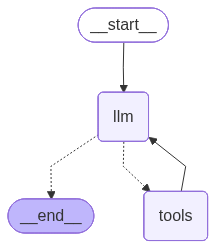

In [228]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))
